# Phase 5: Model Comparison & Evaluation

Compare Baseline (DAPT), Regularized (Phase 2), and Mixed (Phase 4) models on the test split.

Outputs:
- results/model_metrics_table.csv
- results/all_models_comparison.png
- results/per_class_f1_comparison.png
- results/confusion_matrices_all.png
- results/model_comparison_report.md
- results/improvement_summary.json


In [1]:
import os
import json
import numpy as np
import pandas as pd
import torch
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import RobertaForSequenceClassification, RobertaTokenizer
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, confusion_matrix

print("✅ Libraries loaded")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")


✅ Libraries loaded
Device: cuda


## 1) Load test split (from Phase 1) and label encoder


In [ ]:
print("Loading test set from training_data_lang_15pct_1.csv (Phase 1 test split)...")
test_df = pd.read_csv('training_data_lang_15pct_1.csv', keep_default_na=False, na_values=[''])
print(f"\nTrain columns: {list(test_df.columns)}")
# Rename column to match expected format


test_df['frame_label'] = test_df['frame_classification'].fillna('None').replace({'uneindeutig': 'None'})

with open('data/roberta_label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)
labels = list(label_encoder.classes_)

test_df = test_df[['chunk_text','frame_label']].copy()
test_df['label'] = label_encoder.transform(test_df['frame_label'])
print(f"✅ Test size: {len(test_df):,}")
print(f"✅ Consistent with Phase 1/2/3/4 test split")


## 2) Evaluate all models (baseline, regularized, mixed)


In [3]:
def evaluate_model(model_path, test_texts, true_labels):
    print(f"\n{'='*70}\nEvaluating: {model_path}\n{'='*70}")
    tokenizer = RobertaTokenizer.from_pretrained(model_path)
    model = RobertaForSequenceClassification.from_pretrained(model_path)
    model = model.to(device)
    model.eval()

    all_preds = []
    batch_size = 32
    with torch.no_grad():
        for i in range(0, len(test_texts), batch_size):
            batch = test_texts[i:i+batch_size]
            inputs = tokenizer(batch, truncation=True, max_length=384, padding=True, return_tensors='pt')
            inputs = {k: v.to(device) for k, v in inputs.items()}
            outputs = model(**inputs)
            preds = outputs.logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)

    all_preds = np.array(all_preds)
    acc = accuracy_score(true_labels, all_preds)
    f1_macro = f1_score(true_labels, all_preds, average='macro')
    precision, recall, f1, support = precision_recall_fscore_support(true_labels, all_preds, average=None, zero_division=0)
    cm = confusion_matrix(true_labels, all_preds)

    return {
        'predictions': all_preds,
        'accuracy': float(acc),
        'f1_macro': float(f1_macro),
        'per_class_f1': {labels[i]: float(f1[i]) for i in range(len(labels))},
        'per_class_precision': {labels[i]: float(precision[i]) for i in range(len(labels))},
        'per_class_recall': {labels[i]: float(recall[i]) for i in range(len(labels))},
        'confusion_matrix': cm
    }

models = {
    'Baseline (DAPT)': 'models/roberta-optimized',
    'Regularized': 'models/roberta-dapt-regularized',
    'Dynamic (Balanced)': 'models/roberta-dapt-dynamic',
    'Mixed Data': 'models/roberta-mixed-final'
}

results = {}
for name, path in models.items():
    if os.path.exists(path):
        results[name] = evaluate_model(path, test_df['chunk_text'].tolist(), test_df['label'].values)
    else:
        print(f"⚠️  Missing: {name} at {path}")

print("\n✅ Evaluation complete")



Evaluating: models/roberta-optimized

Evaluating: models/roberta-dapt-regularized

Evaluating: models/roberta-dapt-dynamic

Evaluating: models/roberta-mixed-final

✅ Evaluation complete


## 3) Build comparison table and visualizations; save report


✅ Saved results/model_metrics_table.csv
✅ Saved results/all_models_comparison.png
✅ Saved results/per_class_f1_comparison.png
✅ Saved results/confusion_matrices_all.png
✅ Saved report and summary


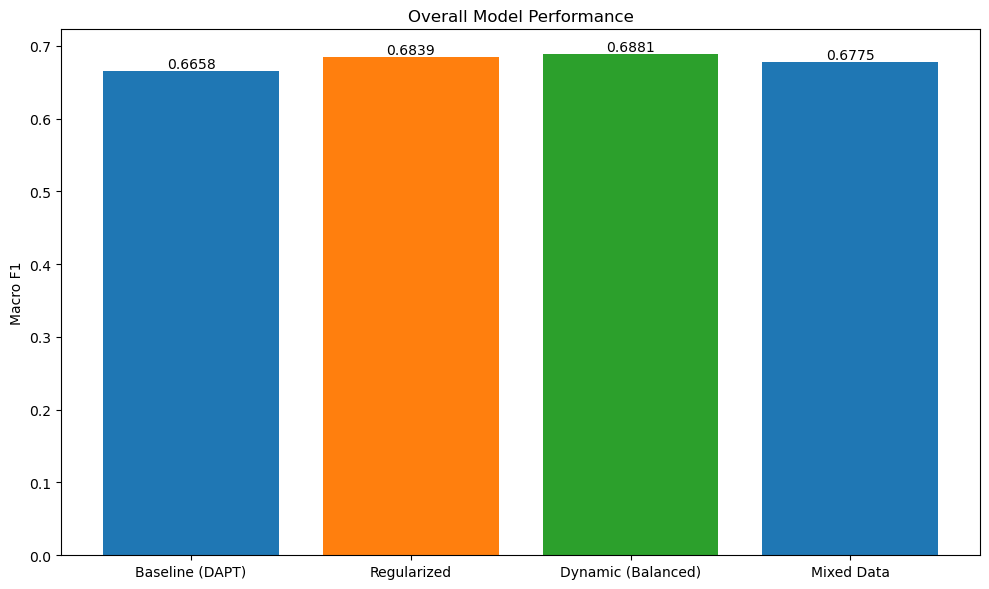

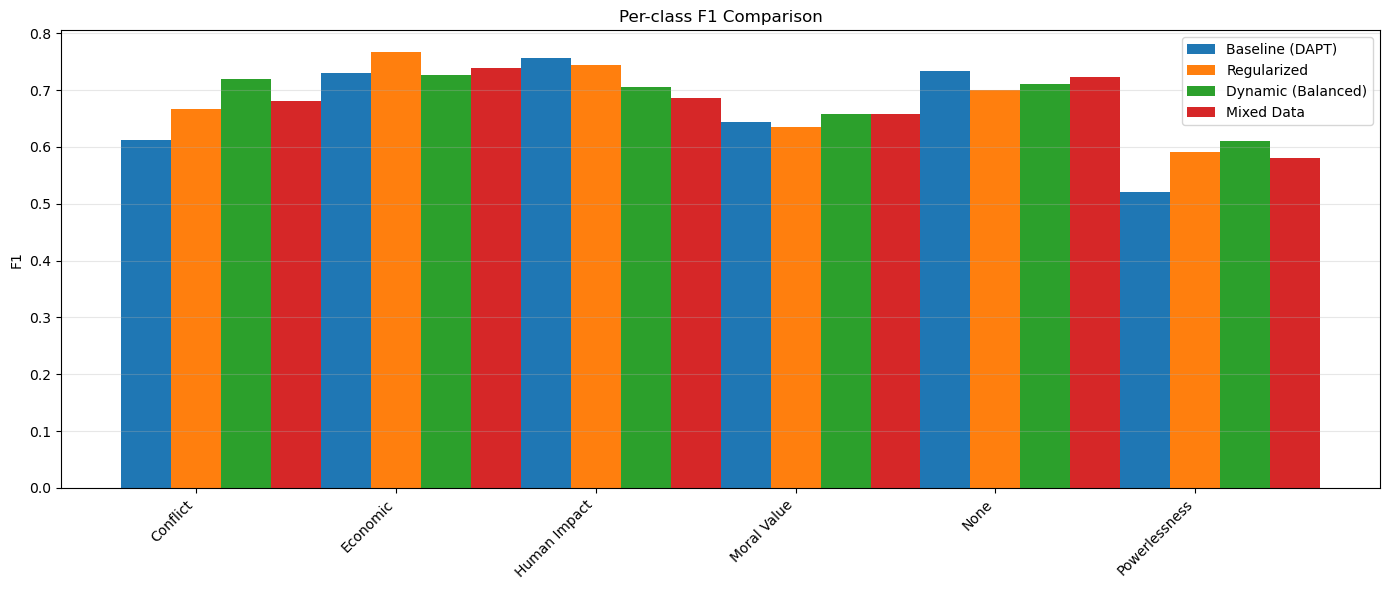

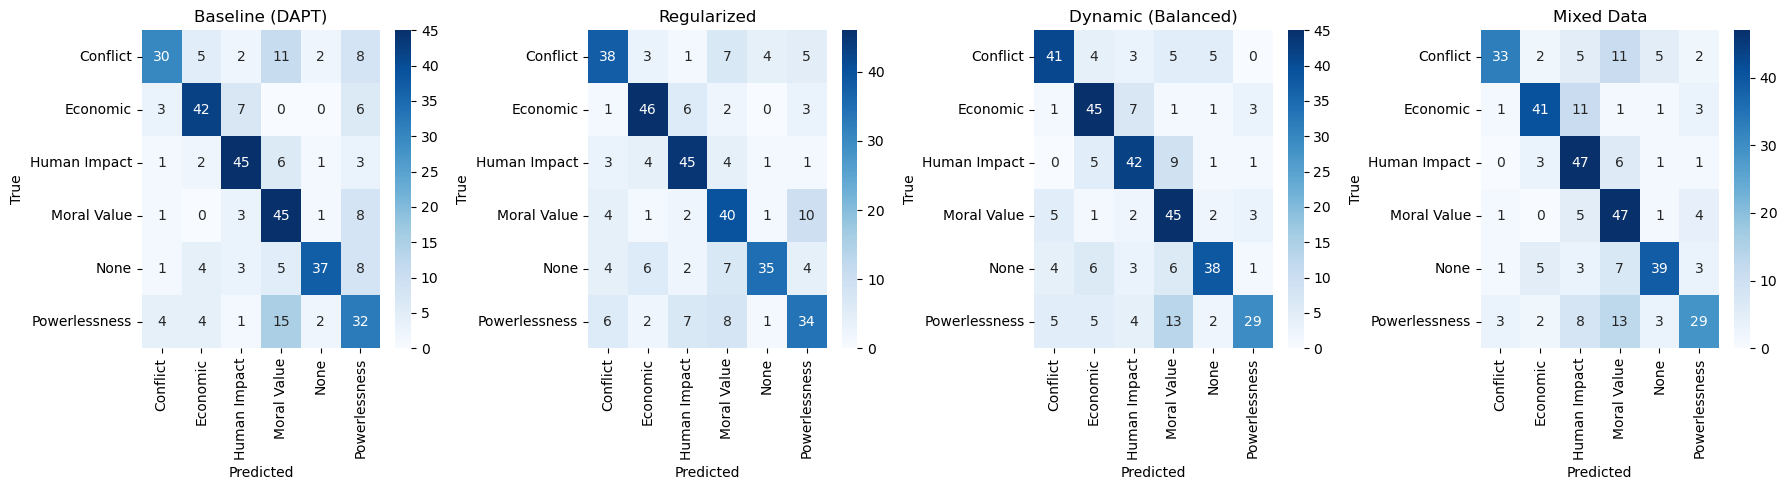

In [4]:
# Comparison table
comparison_rows = []
for model_name, res in results.items():
    row = {'Model': model_name, 'Accuracy': res['accuracy'], 'Macro F1': res['f1_macro']}
    for label in labels:
        row[f'{label} F1'] = res['per_class_f1'][label]
    comparison_rows.append(row)
comparison_df = pd.DataFrame(comparison_rows)

os.makedirs('results', exist_ok=True)
comparison_df.to_csv('results/model_metrics_table.csv', index=False)
print("✅ Saved results/model_metrics_table.csv")

# Visualizations
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(comparison_df['Model'], comparison_df['Macro F1'], color=['#1f77b4','#ff7f0e','#2ca02c'])
ax.set_ylabel('Macro F1')
ax.set_title('Overall Model Performance')
for p in ax.patches:
    ax.text(p.get_x()+p.get_width()/2., p.get_height(), f"{p.get_height():.4f}", ha='center', va='bottom')
plt.tight_layout()
plt.savefig('results/all_models_comparison.png', dpi=300, bbox_inches='tight')
print("✅ Saved results/all_models_comparison.png")

fig, ax = plt.subplots(figsize=(14,6))
x = np.arange(len(labels))
width = 0.25
for i, (model_name, res) in enumerate(results.items()):
    f1s = [res['per_class_f1'][label] for label in labels]
    ax.bar(x + i*width, f1s, width, label=model_name)
ax.set_xticks(x + width)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('F1')
ax.set_title('Per-class F1 Comparison')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/per_class_f1_comparison.png', dpi=300, bbox_inches='tight')
print("✅ Saved results/per_class_f1_comparison.png")

# Confusion matrices
fig, axes = plt.subplots(1, len(results), figsize=(18,5))
if len(results) == 1:
    axes = [axes]
for i, (model_name, res) in enumerate(results.items()):
    cm = res['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[i])
    axes[i].set_title(model_name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')
plt.tight_layout()
plt.savefig('results/confusion_matrices_all.png', dpi=300, bbox_inches='tight')
print("✅ Saved results/confusion_matrices_all.png")

# Report
baseline_f1 = results.get('Baseline (DAPT)', {'f1_macro': np.nan})['f1_macro']
best_model_name = max(results, key=lambda k: results[k]['f1_macro'])
best_f1 = results[best_model_name]['f1_macro']
improvement = (best_f1 - baseline_f1) / baseline_f1 * 100 if baseline_f1 == baseline_f1 else np.nan

report = [
    "# Model Comparison Report\n",
    "\n## Summary\n",
    comparison_df.to_markdown(index=False),
    "\n\n## Best Model\n",
    f"- {best_model_name}: Macro F1 = {best_f1:.4f}\n",
    f"- Improvement over Baseline: {improvement:.1f}%\n" if baseline_f1==baseline_f1 else "- Baseline missing; improvement N/A\n",
]
with open('results/model_comparison_report.md', 'w') as f:
    f.write('\n'.join(report))

with open('results/improvement_summary.json', 'w') as f:
    json.dump({
        'baseline_f1': float(baseline_f1) if baseline_f1==baseline_f1 else None,
        'best_model': best_model_name,
        'best_f1': float(best_f1),
        'improvement_percent': float(improvement) if baseline_f1==baseline_f1 else None
    }, f, indent=2)
print("✅ Saved report and summary")
